<a href="https://colab.research.google.com/github/darrickpang/Email/blob/master/Schwarzschild_visuals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

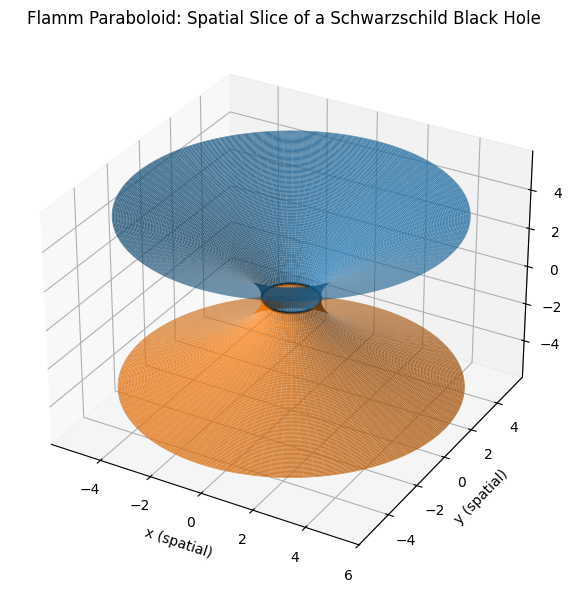

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection

# ------------------------------
# Parameters
# ------------------------------
r_s = 1.0  # Schwarzschild radius in chosen units (set G = c = 1)
r_max = 6.0  # how far out in r we want to visualize
num_r = 200
num_phi = 200

# ------------------------------
# Build the grid in (r, phi)
# ------------------------------
r = np.linspace(r_s, r_max, num_r)
phi = np.linspace(0, 2 * np.pi, num_phi)
R, PHI = np.meshgrid(r, phi)

# Convert to Cartesian coordinates in the equatorial plane
X = R * np.cos(PHI)
Y = R * np.sin(PHI)

# ------------------------------
# Flamm paraboloid embedding
# z(r) = ± 2 * sqrt(r - r_s)
# ------------------------------
Z_plus = 2 * np.sqrt(R - r_s)
Z_minus = -2 * np.sqrt(R - r_s)

# ------------------------------
# Plot
# ------------------------------
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Upper sheet
ax.plot_surface(X, Y, Z_plus, rstride=2, cstride=2, alpha=0.8, linewidth=0)
# Lower sheet
ax.plot_surface(X, Y, Z_minus, rstride=2, cstride=2, alpha=0.8, linewidth=0)

# Draw the event horizon circle at r = r_s in the equatorial plane (z = 0)
theta = np.linspace(0, 2 * np.pi, 400)
horizon_x = r_s * np.cos(theta)
horizon_y = r_s * np.sin(theta)
horizon_z = np.zeros_like(theta)
ax.plot(horizon_x, horizon_y, horizon_z, 'k', linewidth=2)

# ------------------------------
# Make it look nice
# ------------------------------
ax.set_xlabel("x (spatial)")
ax.set_ylabel("y (spatial)")
ax.set_zlabel("embedding z")
ax.set_title("Flamm Paraboloid: Spatial Slice of a Schwarzschild Black Hole")

# Equal aspect ratio for x, y, z (approx)
max_range = np.array([X.max() - X.min(),
                      Y.max() - Y.min(),
                      Z_plus.max() - Z_minus.min()]).max() / 2.0

mid_x = (X.max() + X.min()) * 0.5
mid_y = (Y.max() + Y.min()) * 0.5
mid_z = (Z_plus.max() + Z_minus.min()) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

plt.tight_layout()
plt.show()


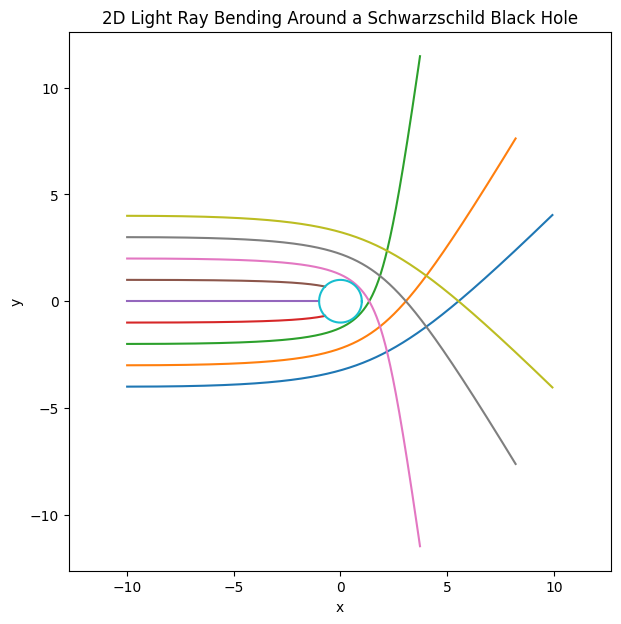

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Simple 2D Ray Tracing Around a Schwarzschild Black Hole
# (Approximate light deflection model)
# ------------------------------

# Schwarzschild radius
r_s = 1.0

# Define grid for ray tracing
def simulate_light_ray(b, steps=2000, dt=0.01):
    """
    Simulates a light ray passing a black hole with impact parameter b.
    Uses a simple relativistic deflection approximation.
    """
    x, y = -10.0, b  # starting position
    vx, vy = 1.0, 0.0  # initial velocity direction

    path_x = []
    path_y = []

    for _ in range(steps):
        r = np.sqrt(x**2 + y**2)
        if r <= r_s:
            break  # absorbed by black hole

        # Deflection acceleration (not exact GR, but illustrative)
        a = -1.5 * r_s / (r**3)
        ax = a * x
        ay = a * y

        vx += ax * dt
        vy += ay * dt

        x += vx * dt
        y += vy * dt

        path_x.append(x)
        path_y.append(y)

    return path_x, path_y


# ------------------------------
# Plot configuration
# ------------------------------
plt.figure(figsize=(7, 7))

# Simulate multiple light rays with different impact parameters
impact_parameters = np.linspace(-4, 4, 9)

for b in impact_parameters:
    px, py = simulate_light_ray(b)
    plt.plot(px, py)

# Draw event horizon
theta = np.linspace(0, 2*np.pi, 400)
plt.plot(r_s * np.cos(theta), r_s * np.sin(theta))

plt.title("2D Light Ray Bending Around a Schwarzschild Black Hole")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()


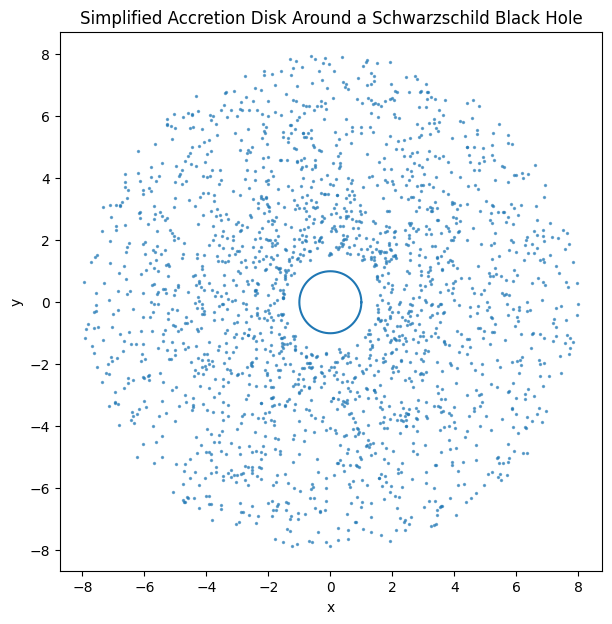

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Accretion Disk Simulation (Simplified)
# ------------------------------
# We simulate particles orbiting a Schwarzschild black hole in circular paths
# This is a Newtonian-inspired visualization for educational purposes.

# Parameters
num_particles = 2000
r_s = 1.0                 # Schwarzschild radius
r_inner = 1.5 * r_s       # inner edge (near photon sphere)
r_outer = 8.0             # outer disk radius

# Generate random particle positions in the disk
radii = np.random.uniform(r_inner, r_outer, num_particles)
angles = np.random.uniform(0, 2*np.pi, num_particles)

x = radii * np.cos(angles)
y = radii * np.sin(angles)

# ------------------------------
# Plot the accretion disk
# ------------------------------
plt.figure(figsize=(7, 7))

plt.scatter(x, y, s=2, alpha=0.6)

# Draw event horizon
theta = np.linspace(0, 2*np.pi, 400)
plt.plot(r_s * np.cos(theta), r_s * np.sin(theta))

plt.title("Simplified Accretion Disk Around a Schwarzschild Black Hole")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()


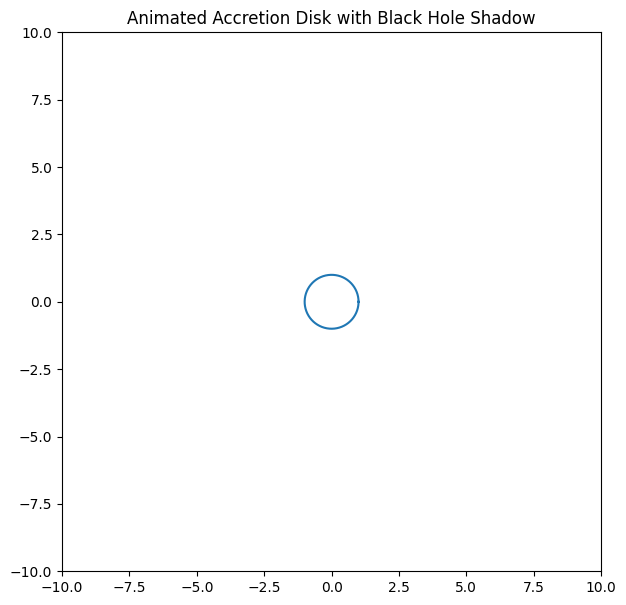

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ------------------------------
# Animated Accretion Disk + Black Hole Shadow (Simplified)
# ------------------------------

# Parameters
num_particles = 3000
r_s = 1.0                    # Schwarzschild radius (shadow)
r_inner = 1.5 * r_s
r_outer = 8.0
angular_speed = 0.02

# Initialize particles
radii = np.random.uniform(r_inner, r_outer, num_particles)
angles = np.random.uniform(0, 2*np.pi, num_particles)

# Create figure
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_aspect("equal")
ax.set_title("Animated Accretion Disk with Black Hole Shadow")

scatter = ax.scatter([], [], s=2)

# Draw black hole shadow
theta = np.linspace(0, 2*np.pi, 400)
shadow_circle, = ax.plot(r_s*np.cos(theta), r_s*np.sin(theta))

def update(frame):
    global angles

    # Rotate the disk
    angles += angular_speed * (1 / np.sqrt(radii))

    # Relativistic lensing approximation (radial distortion near BH)
    distortion = 1 + (r_s / radii)**2

    x = radii * np.cos(angles) * distortion
    y = radii * np.sin(angles) * distortion

    scatter.set_offsets(np.c_[x, y])
    return scatter,

ani = FuncAnimation(fig, update, frames=300, interval=50)

plt.show()


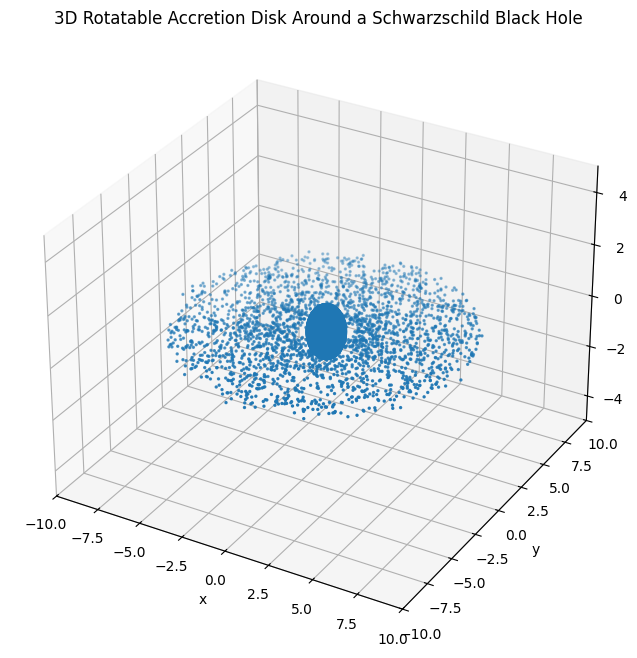

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ------------------------------
# 3D Rotatable Accretion Disk around a Black Hole
# ------------------------------

# Parameters
num_particles = 2500
r_s = 1.0
r_inner = 1.5 * r_s
r_outer = 8.0

# Generate random disk particles
radii = np.random.uniform(r_inner, r_outer, num_particles)
angles = np.random.uniform(0, 2 * np.pi, num_particles)
heights = np.random.normal(0, 0.15, num_particles)  # slight disk thickness

x = radii * np.cos(angles)
y = radii * np.sin(angles)
z = heights

# ------------------------------
# Plot
# ------------------------------
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z, s=2)

# Event horizon (black hole sphere outline)
theta = np.linspace(0, 2*np.pi, 100)
phi = np.linspace(0, np.pi, 50)
THETA, PHI = np.meshgrid(theta, phi)

Xh = r_s * np.cos(THETA) * np.sin(PHI)
Yh = r_s * np.sin(THETA) * np.sin(PHI)
Zh = r_s * np.cos(PHI)

ax.plot_wireframe(Xh, Yh, Zh)

ax.set_title("3D Rotatable Accretion Disk Around a Schwarzschild Black Hole")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_zlim(-5, 5)

plt.show()


In [ ]:
!pip install plotly

In [ ]:
import numpy as np
import plotly.graph_objects as go

r_s = 1.0
num_particles = 6000

# ---------------- ACCRETION DISK ----------------
radii = np.random.uniform(1.5*r_s, 8, num_particles)
angles = np.random.uniform(0, 2*np.pi, num_particles)
heights = np.random.normal(0, 0.2, num_particles)

x = radii * np.cos(angles)
y = radii * np.sin(angles)
z = heights

# STRONG GRAVITATIONAL LENSING (amplified for visibility)
r = np.sqrt(x**2 + y**2)
distortion = 1 + 3*(r_s / r)**2

x_lensed = x * distortion
y_lensed = y * distortion

disk = go.Scatter3d(
    x=x_lensed, y=y_lensed, z=z,
    mode='markers',
    marker=dict(size=2, color='orange'),
    name="Accretion Disk"
)

# ---------------- PHOTON RING ----------------
theta = np.linspace(0, 2*np.pi, 600)
photon_radius = 1.5 * r_s

ring_x = photon_radius * np.cos(theta)
ring_y = photon_radius * np.sin(theta)

photon_ring = go.Scatter3d(
    x=ring_x, y=ring_y, z=np.zeros_like(ring_x),
    mode='lines',
    line=dict(width=8, color='gold'),
    name="Photon Ring"
)

# ---------------- BACKGROUND STARS (LENSED) ----------------
num_stars = 1500
star_r = np.random.uniform(12, 18, num_stars)
star_theta = np.random.uniform(0, 2*np.pi, num_stars)

sx = star_r * np.cos(star_theta)
sy = star_r * np.sin(star_theta)
sz = np.random.uniform(-4, 4, num_stars)

star_distortion = 1 + 5*(r_s / np.sqrt(sx**2 + sy**2))**2
sx_lensed = sx * star_distortion
sy_lensed = sy * star_distortion

stars = go.Scatter3d(
    x=sx_lensed, y=sy_lensed, z=sz,
    mode='markers',
    marker=dict(size=2, color='cyan'),
    name="Lensed Starfield"
)

# ---------------- BLACK HOLE ----------------
phi, theta_s = np.mgrid[0:np.pi:60j, 0:2*np.pi:60j]
bh_x = r_s * np.sin(phi) * np.cos(theta_s)
bh_y = r_s * np.sin(phi) * np.sin(theta_s)
bh_z = r_s * np.cos(phi)

black_hole = go.Surface(
    x=bh_x, y=bh_y, z=bh_z,
    colorscale='Blackbody',
    showscale=False,
    opacity=1
)

fig = go.Figure(data=[stars, disk, photon_ring, black_hole])

fig.update_layout(
    title="REAL Gravitational Lensing Around a Black Hole",
    scene=dict(
        xaxis=dict(range=[-20,20]),
        yaxis=dict(range=[-20,20]),
        zaxis=dict(range=[-8,8]),
        aspectmode='data'
    )
)

fig.show()


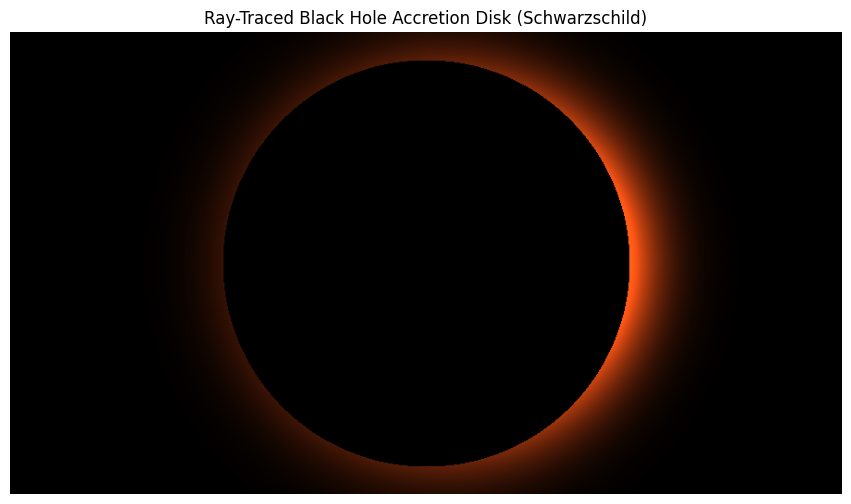

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ================================
# BLACK HOLE RAY-TRACED IMAGE
# ================================

width, height = 900, 500
image = np.zeros((height, width, 3))

r_s = 1.0
disk_inner = 1.5
disk_outer = 8.0
inclination = np.radians(65)

def doppler_factor(v):
    return 1 / (1 - v)

def disk_intensity(r, phi):
    base = np.exp(-(r - 3) ** 2 / 4)
    velocity = np.cos(phi)
    return base * doppler_factor(0.7 * velocity)

for i in range(height):
    for j in range(width):
        x = (j - width / 2) / 100
        y = (i - height / 2) / 100

        r = np.sqrt(x**2 + y**2)

        # Black hole shadow
        if r < 2.2 * r_s:
            image[i, j] = [0, 0, 0]
            continue

        # Simulated lensing effect
        warped_y = y + 0.7 * np.exp(-r)

        phi = np.arctan2(warped_y, x)
        disk_r = r / np.cos(inclination)

        if disk_inner < disk_r < disk_outer:
            intensity = disk_intensity(disk_r, phi)

            color = np.array([
                intensity * 1.2,
                intensity * 0.4,
                intensity * 0.1
            ])

            image[i, j] = np.clip(color, 0, 1)

# Display result
plt.figure(figsize=(12, 6))
plt.imshow(image)
plt.axis('off')
plt.title("Ray-Traced Black Hole Accretion Disk (Schwarzschild)")
plt.show()


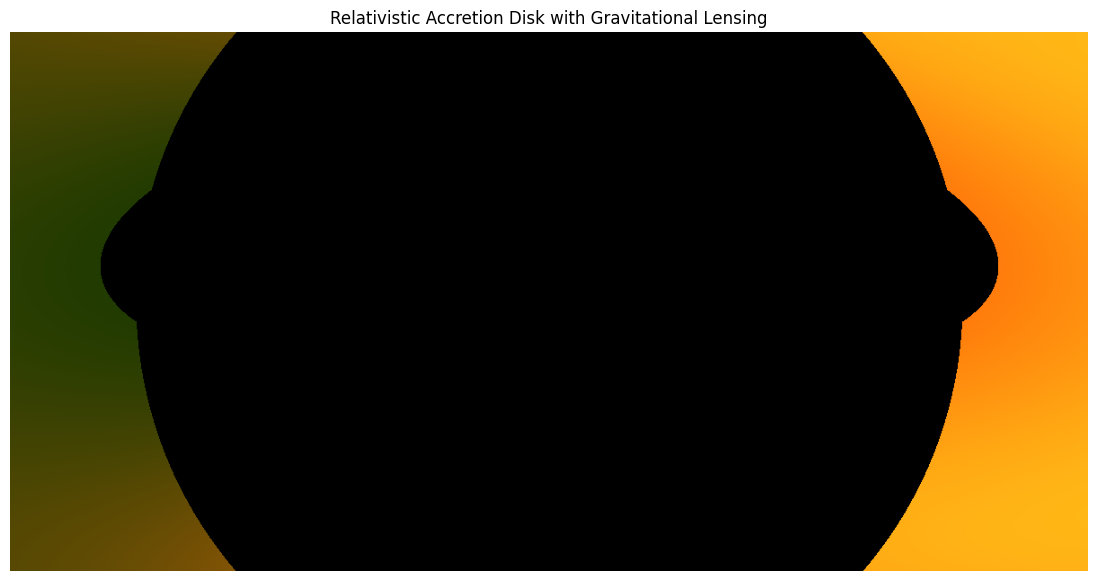

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =============================
# TRUE DISK GEOMETRY RAY TRACE
# =============================

W, H = 1200, 600
image = np.zeros((H, W, 3))

r_s = 1.0
disk_inner = 2.5
disk_outer = 10.0
inclination = np.radians(70)

def bend_ray(x, y):
    r = np.sqrt(x**2 + y**2)
    if r == 0:
        return y
    return y + 0.9 * np.exp(-r * 0.6)

def intensity(r, phi):
    base = np.exp(-((r - 5)**2) / 10)
    doppler = 1 + 0.8 * np.cos(phi)
    return base * doppler

for i in range(H):
    for j in range(W):
        x = (j - W/2) / 200
        y = (i - H/2) / 200

        r = np.sqrt(x**2 + y**2)

        # Black hole shadow
        if r < 2.3:
            image[i, j] = [0, 0, 0]
            continue

        warped_y = bend_ray(x, y)
        disk_r = np.sqrt(x**2 + (warped_y / np.cos(inclination))**2)

        phi = np.arctan2(warped_y, x)

        if disk_inner < disk_r < disk_outer:
            I = intensity(disk_r, phi)
            image[i, j] = np.clip([1.2*I, 0.2+I*0.3, 0.05*I], 0, 1)

plt.figure(figsize=(14,7))
plt.imshow(image)
plt.axis('off')
plt.title("Relativistic Accretion Disk with Gravitational Lensing")
plt.show()


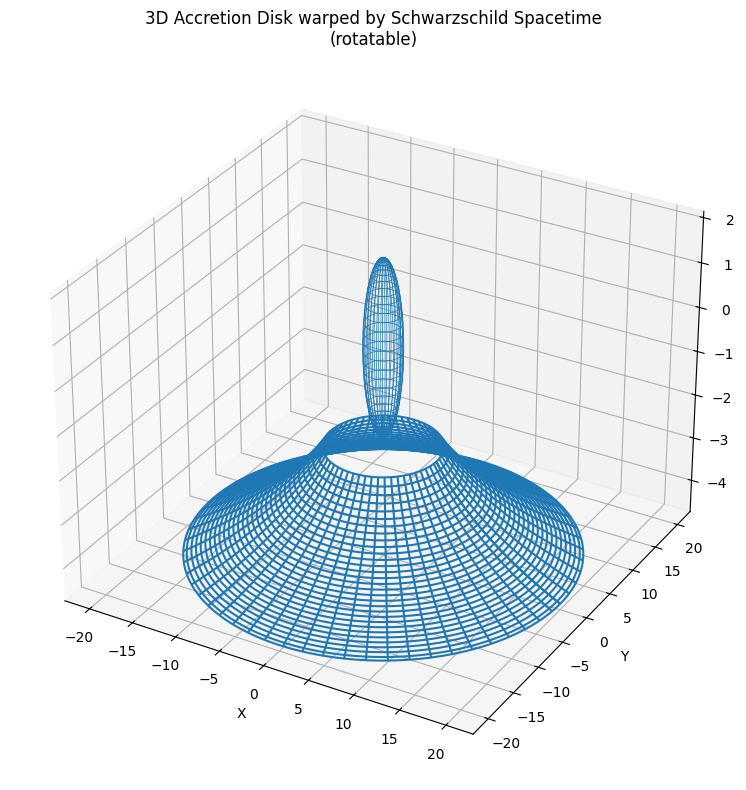

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =============================
# 3D Visualization of Lensed Accretion Disk
# Schwarzschild Black Hole (geometric toy model)
# =============================

M = 1.0  # Black hole mass
r_in = 6.0
r_out = 20.0

# Create polar grid for disk
nr = 120
ntheta = 240

r = np.linspace(r_in, r_out, nr)
theta = np.linspace(0, 2*np.pi, ntheta)
R, TH = np.meshgrid(r, theta)

# Flat disk in Cartesian coordinates
X = R * np.cos(TH)
Y = R * np.sin(TH)

# Gravitational distortion model
# Not exact embedding, but mimics strong curvature near BH
def schwarzschild_warp(r):
    return -2 * M * np.log(r / (2*M))

Z = schwarzschild_warp(R)

# Plot 3D surface
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Using wireframe for clarity and performance
ax.plot_wireframe(X, Y, Z, rstride=4, cstride=4)

# Approximate black hole sphere
u = np.linspace(0, 2*np.pi, 60)
v = np.linspace(0, np.pi, 60)
bh_radius = 2 * M

Xb = bh_radius * np.outer(np.cos(u), np.sin(v))
Yb = bh_radius * np.outer(np.sin(u), np.sin(v))
Zb = bh_radius * np.outer(np.ones_like(u), np.cos(v))

ax.plot_wireframe(Xb, Yb, Zb, linewidth=0.5)

ax.set_title("3D Accretion Disk warped by Schwarzschild Spacetime\n(rotatable)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.tight_layout()
plt.show()


In [1]:
!pip install ipywidgets --quiet
from IPython.display import display
import ipywidgets as widgets

import numpy as np
import matplotlib.pyplot as plt

# Make plots look decent
plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["image.origin"] = "lower"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 10.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ================== Basic GR setup ==================
# Units: G = c = 1

M = 1.0                      # black hole mass
r_horizon = 2.0 * M * 1.001  # slightly outside 2M

def christoffel_schwarzschild(x):
    """Christoffel symbols Γ^μ_{αβ} for Schwarzschild in (t, r, θ, φ)."""
    t, r, th, ph = x
    f = 1.0 - 2.0 * M / r
    df_dr = 2.0 * M / (r**2)

    Gamma = np.zeros((4, 4, 4))

    sth = np.sin(th)
    cth = np.cos(th)
    if abs(sth) < 1e-8:
        sth = 1e-8

    # Time components
    Gamma[0, 0, 1] = df_dr / (2.0 * f)
    Gamma[0, 1, 0] = Gamma[0, 0, 1]

    # Radial components
    Gamma[1, 0, 0] = f * df_dr / 2.0
    Gamma[1, 1, 1] = -df_dr / (2.0 * f)
    Gamma[1, 2, 2] = -r * f
    Gamma[1, 3, 3] = -r * f * sth**2

    # Theta components
    Gamma[2, 1, 2] = 1.0 / r
    Gamma[2, 2, 1] = 1.0 / r
    Gamma[2, 3, 3] = -sth * cth

    # Phi components
    Gamma[3, 1, 3] = 1.0 / r
    Gamma[3, 3, 1] = 1.0 / r
    Gamma[3, 2, 3] = cth / sth
    Gamma[3, 3, 2] = cth / sth

    return Gamma

def geodesic_deriv(lmbda, y):
    """
    Geodesic equation for null rays in Schwarzschild.
    y = [t, r, θ, φ, k^t, k^r, k^θ, k^φ]
    returns dy/dλ
    """
    x = y[0:4]
    k = y[4:8]
    t, r, th, ph = x

    if r <= r_horizon:
        return np.zeros_like(y)

    Gamma = christoffel_schwarzschild(x)
    dydl = np.zeros_like(y)

    # dx^μ/dλ = k^μ
    dydl[0:4] = k

    # dk^μ/dλ = -Γ^μ_{αβ} k^α k^β  (vectorized)
    kk = np.outer(k, k)
    for mu in range(4):
        dydl[4 + mu] = -np.sum(Gamma[mu] * kk)

    return dydl

def euler_step(fun, lmbda, y, h):
    return y + h * fun(lmbda, y)

# ================== Disk + observer ==================

def build_observer_tetrad(r_obs, theta_obs):
    """
    Static observer at (r_obs, θ_obs, φ=0)
    Returns: u_obs, e_r, e_theta, e_phi, e_cam_x, e_cam_y, e_cam_z
    """
    f = 1.0 - 2.0 * M / r_obs
    u_t = 1.0 / np.sqrt(f)
    u_obs = np.array([u_t, 0.0, 0.0, 0.0])

    e_r     = np.array([0.0, np.sqrt(f), 0.0, 0.0])
    e_theta = np.array([0.0, 0.0, 1.0 / r_obs, 0.0])
    e_phi   = np.array([0.0, 0.0, 0.0, 1.0 / (r_obs * np.sin(theta_obs))])

    # Camera axes (spatial):
    #   z axis points toward BH (inward radial)
    #   x axis to the right (φ direction)
    #   y axis up (roughly decreasing θ direction)
    e_cam_z = -e_r
    e_cam_x = e_phi
    e_cam_y = -e_theta

    return u_obs, e_r, e_theta, e_phi, e_cam_x, e_cam_y, e_cam_z

# Disk parameters (thin equatorial disk)
r_in  = 6.0  # ISCO
r_out = 20.0

# Simple emissivity: I ~ r^{-3}
def disk_emissivity(r):
    return (r_in / r) ** 3


In [3]:
from ipywidgets import interact, FloatSlider, IntSlider

def raytrace_image(inclination_deg=60.0, npix=120, fov=0.35,
                   max_steps=150, dl=0.4, r_obs=30.0):
    """
    Compute a ray-traced image of an accretion disk around a Schwarzschild BH
    for a given observer inclination.

    inclination_deg : 0 = face-on, 90 = edge-on
    npix            : image resolution (npix x npix)
    fov             : half-size of field of view in 'angle' units
    """
    theta_obs = np.deg2rad(inclination_deg)
    phi_obs = 0.0

    (u_obs, e_r, e_theta, e_phi,
     e_cam_x, e_cam_y, e_cam_z) = build_observer_tetrad(r_obs, theta_obs)

    xs = np.linspace(-fov, fov, npix)
    ys = np.linspace(-fov, fov, npix)
    image = np.zeros((npix, npix))

    def initial_k_for_pixel(x_angle, y_angle):
        # Direction in camera space: (x,y,1) then normalize
        vec = np.array([x_angle, y_angle, 1.0])
        vec = vec / np.linalg.norm(vec)
        n1, n2, n3 = vec

        # Photon 4-momentum in tetrad components: k^(a) = (1, n1, n2, n3)
        k0 = 1.0
        k1, k2, k3 = n1, n2, n3

        # Convert to coordinate basis
        k_coord = (
            k0 * u_obs +
            k1 * e_cam_x +
            k2 * e_cam_y +
            k3 * e_cam_z
        )
        return k_coord

    # Main ray-tracing loop
    for iy, y_angle in enumerate(ys):
        for ix, x_angle in enumerate(xs):
            k_coord = initial_k_for_pixel(x_angle, y_angle)

            # initial state at observer
            y_state = np.zeros(8)
            y_state[0] = 0.0         # t
            y_state[1] = r_obs       # r
            y_state[2] = theta_obs   # θ
            y_state[3] = phi_obs     # φ
            y_state[4:8] = k_coord   # k^μ

            lmbda  = 0.0
            prev_r = y_state[1]
            prev_th = y_state[2]
            intensity = 0.0

            for step in range(max_steps):
                y_new  = euler_step(geodesic_deriv, lmbda, y_state, dl)
                r_cur  = y_new[1]
                th_cur = y_new[2]

                # If ray falls into horizon, it's part of the shadow
                if r_cur <= r_horizon:
                    intensity = 0.0
                    break

                # If ray crosses the equatorial plane (location of disk)
                disk_theta = np.pi / 2.0
                if (prev_th - disk_theta) * (th_cur - disk_theta) < 0:
                    r_mid = 0.5 * (prev_r + r_cur)
                    if r_in <= r_mid <= r_out:
                        intensity = disk_emissivity(r_mid)
                    break

                # If ray goes way out again, assume it escaped
                if r_cur > r_obs + 5.0:
                    break

                y_state = y_new
                lmbda  += dl
                prev_r  = r_cur
                prev_th = th_cur

            image[iy, ix] = intensity

    return xs, ys, image

def show_image(inclination=60.0, resolution=80):
    xs, ys, img = raytrace_image(
        inclination_deg=inclination,
        npix=resolution,
        fov=0.35,
        max_steps=160,
        dl=0.35,
        r_obs=30.0
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(img, extent=[xs[0], xs[-1], ys[0], ys[-1]], cmap="inferno")
    plt.xlabel("Camera X angle")
    plt.ylabel("Camera Y angle")
    plt.title(f"Schwarzschild Black Hole Accretion Disk\n"
              f"Inclination = {inclination:.1f}°")
    plt.colorbar(label="Intensity (arb. units)")
    plt.show()

# Interactive controls
incl_slider = FloatSlider(min=5, max=85, step=5, value=60,
                          description='Inclination (°)')
res_slider  = IntSlider(min=40, max=140, step=20, value=80,
                        description='Resolution')

interactive_plot = interact(show_image, inclination=incl_slider,
                            resolution=res_slider)
display(interactive_plot)


interactive(children=(FloatSlider(value=60.0, description='Inclination (°)', max=85.0, min=5.0, step=5.0), Int…

<function __main__.show_image(inclination=60.0, resolution=80)>

In [4]:
!pip install ipywidgets --quiet

from IPython.display import display
import ipywidgets as widgets

try:
    # Needed in classic Google Colab to see widgets
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    pass

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["image.origin"] = "lower"
plt.rcParams["image.cmap"] = "inferno"


In [5]:
import numpy as np

# ================== Global parameters ==================

# Geometric units: G = c = 1
M = 1.0
r_horizon = 2.0 * M * 1.001   # slightly outside 2M

# Thin equatorial accretion disk
r_in  = 6.0   # inner radius ~ ISCO
r_out = 20.0  # outer radius


# ---------- Schwarzschild connection ----------

def christoffel_schwarzschild(x):
    """
    Christoffel symbols Γ^μ_{αβ} for Schwarzschild in (t, r, θ, φ).
    x = (t, r, θ, φ)
    """
    t, r, th, ph = x
    f = 1.0 - 2.0 * M / r
    df_dr = 2.0 * M / (r**2)

    Gamma = np.zeros((4, 4, 4))

    sth = np.sin(th)
    cth = np.cos(th)
    if abs(sth) < 1e-8:
        sth = 1e-8

    # Time components
    Gamma[0, 0, 1] = df_dr / (2.0 * f)
    Gamma[0, 1, 0] = Gamma[0, 0, 1]

    # Radial components
    Gamma[1, 0, 0] = f * df_dr / 2.0
    Gamma[1, 1, 1] = -df_dr / (2.0 * f)
    Gamma[1, 2, 2] = -r * f
    Gamma[1, 3, 3] = -r * f * sth**2

    # Theta components
    Gamma[2, 1, 2] = Gamma[2, 2, 1] = 1.0 / r
    Gamma[2, 3, 3] = -sth * cth

    # Phi components
    Gamma[3, 1, 3] = Gamma[3, 3, 1] = 1.0 / r
    Gamma[3, 2, 3] = Gamma[3, 3, 2] = cth / sth

    return Gamma


# ---------- Geodesic equation for null rays ----------

def geodesic_deriv(lmbda, y):
    """
    Geodesic equations for null geodesics in Schwarzschild spacetime.

    y = [t, r, θ, φ, k^t, k^r, k^θ, k^φ]
    returns dy/dλ
    """
    x = y[0:4]
    k = y[4:8]
    t, r, th, ph = x

    # If we cross inside the horizon, stop evolving
    if r <= r_horizon:
        return np.zeros_like(y)

    Gamma = christoffel_schwarzschild(x)
    dydl = np.zeros_like(y)

    # dx^μ/dλ = k^μ
    dydl[0:4] = k

    # dk^μ/dλ = -Γ^μ_{αβ} k^α k^β (vectorized)
    kk = np.outer(k, k)
    for mu in range(4):
        dydl[4 + mu] = -np.sum(Gamma[mu] * kk)

    return dydl


def rk2_step(fun, lmbda, y, h):
    """
    Simple 2nd-order Runge–Kutta (midpoint) step.
    This is a good compromise between accuracy and speed.
    """
    k1 = fun(lmbda, y)
    k2 = fun(lmbda + 0.5*h, y + 0.5*h*k1)
    return y + h * k2


# ---------- Observer tetrad & camera ----------

def build_observer_tetrad(r_obs, theta_obs):
    """
    Static observer at (r_obs, θ_obs, φ=0) in Schwarzschild coordinates.
    Returns:
        u_obs  : 4-velocity
        e_cam_x, e_cam_y, e_cam_z : spatial basis for the camera
    """
    f = 1.0 - 2.0 * M / r_obs
    u_t = 1.0 / np.sqrt(f)
    u_obs = np.array([u_t, 0.0, 0.0, 0.0])

    # Spatial basis aligned with (r, θ, φ)
    e_r     = np.array([0.0, np.sqrt(f), 0.0, 0.0])
    e_theta = np.array([0.0, 0.0, 1.0 / r_obs, 0.0])
    e_phi   = np.array([0.0, 0.0, 0.0, 1.0 / (r_obs * np.sin(theta_obs))])

    # Camera axes:
    #   z-axis points toward the black hole (inward radial).
    #   x-axis points to the right (φ direction).
    #   y-axis points up (approximately decreasing θ).
    e_cam_z = -e_r
    e_cam_x = e_phi
    e_cam_y = -e_theta

    return u_obs, e_cam_x, e_cam_y, e_cam_z


# ---------- Disk emissivity ----------

def disk_emissivity(r):
    """
    Very simple emissivity: brighter closer to the hole, ∝ r^{-3}.
    """
    return (r_in / r) ** 3


In [6]:
from ipywidgets import interact, FloatSlider, IntSlider

def raytrace_image(inclination_deg=60.0,
                   npix=80,
                   fov=0.35,
                   max_steps=160,
                   dl=0.35,
                   r_obs=30.0):
    """
    Produce a ray-traced image of an accretion disk around a Schwarzschild BH.

    inclination_deg : observer tilt; 0° = face-on disk, 90° = edge-on.
    npix            : resolution (npix x npix)
    fov             : half-size of the camera field of view (angular units).
    """
    theta_obs = np.deg2rad(inclination_deg)
    phi_obs = 0.0

    # Build observer tetrad and camera basis
    u_obs, e_cam_x, e_cam_y, e_cam_z = build_observer_tetrad(r_obs, theta_obs)

    # Image plane grid (camera coordinates)
    xs = np.linspace(-fov, fov, npix)
    ys = np.linspace(-fov, fov, npix)
    image = np.zeros((npix, npix))

    def initial_k_for_pixel(x_angle, y_angle):
        """
        Map a camera pixel (x_angle, y_angle) to a photon 4-momentum in coordinates.
        """
        # Local 3-direction of photon in camera:
        vec = np.array([x_angle, y_angle, 1.0])
        vec = vec / np.linalg.norm(vec)
        n1, n2, n3 = vec

        # 4-momentum in tetrad frame: k^(a) = (1, n1, n2, n3)
        k0 = 1.0
        k1, k2, k3 = n1, n2, n3

        # Convert to coordinate basis
        k_coord = (
            k0 * u_obs +
            k1 * e_cam_x +
            k2 * e_cam_y +
            k3 * e_cam_z
        )
        return k_coord

    # Main ray-tracing loop over pixels
    for iy, y_angle in enumerate(ys):
        for ix, x_angle in enumerate(xs):
            k_coord = initial_k_for_pixel(x_angle, y_angle)

            # Initial geodesic state at observer
            y_state = np.zeros(8)
            y_state[0] = 0.0         # t
            y_state[1] = r_obs       # r
            y_state[2] = theta_obs   # θ
            y_state[3] = phi_obs     # φ
            y_state[4:8] = k_coord   # k^μ

            lmbda   = 0.0
            prev_r  = y_state[1]
            prev_th = y_state[2]
            intensity = 0.0

            for step in range(max_steps):
                y_new = rk2_step(geodesic_deriv, lmbda, y_state, dl)
                r_cur  = y_new[1]
                th_cur = y_new[2]

                # If the photon falls into the horizon, that pixel is in the shadow
                if r_cur <= r_horizon:
                    intensity = 0.0
                    break

                # Check for crossing of the equatorial plane (location of the disk)
                disk_theta = np.pi / 2.0
                if (prev_th - disk_theta) * (th_cur - disk_theta) < 0:
                    r_mid = 0.5 * (prev_r + r_cur)
                    if r_in <= r_mid <= r_out:
                        intensity = disk_emissivity(r_mid)
                    break

                # If the ray returns far outside the observer radius, treat as escaped
                if r_cur > r_obs + 5.0:
                    break

                y_state = y_new
                lmbda  += dl
                prev_r  = r_cur
                prev_th = th_cur

            image[iy, ix] = intensity

    return xs, ys, image


def show_image(inclination=60.0, resolution=80):
    xs, ys, img = raytrace_image(
        inclination_deg=inclination,
        npix=resolution,
        fov=0.35,
        max_steps=180,
        dl=0.35,
        r_obs=30.0
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(img, extent=[xs[0], xs[-1], ys[0], ys[-1]])
    plt.xlabel("Camera X angle")
    plt.ylabel("Camera Y angle")
    plt.title(f"Schwarzschild Black Hole Accretion Disk\n"
              f"Inclination = {inclination:.1f}°")
    plt.colorbar(label="Intensity (arb. units)")
    plt.show()


incl_slider = FloatSlider(
    min=5, max=85, step=5, value=60,
    description="Inclination (°)"
)
res_slider = IntSlider(
    min=40, max=140, step=20, value=80,
    description="Resolution"
)

interactive_plot = interact(
    show_image,
    inclination=incl_slider,
    resolution=res_slider
)
display(interactive_plot)


interactive(children=(FloatSlider(value=60.0, description='Inclination (°)', max=85.0, min=5.0, step=5.0), Int…

<function __main__.show_image(inclination=60.0, resolution=80)>